In [87]:
import numpy as np
import matplotlib.pyplot as plt
import re

class Polygon:
    def __init__(self, points):
        self.points = points
        if len(points)>0:
            self.points.append(points[0])
            self.xs = [point[0] for point in self.points]
            self.ys = [point[1] for point in self.points]
        else:
            self.xs = []
            self.ys = []

class Frame:
    def __init__(self, frame_points):
        self.frame = frame_points
        self.frame.append(frame_points[0])
        self.xs = [point[0] for point in self.frame]
        self.ys = [point[1] for point in self.frame]

class State:
    def __init__(self, frame, used_polys):
        self.frame = frame
        self.used_polys = used_polys

        
        

with open("polys.dat", "r") as f:
    states = f.read().splitlines()
    states_list = []

    for state in states:

        # Find the frame
        frame_points = []
        frame_txt = re.findall(r'\{([^\{]+)\}', state)[0]
        points = re.findall(r'\(([^\)]+)\)', frame_txt)
        for point in points:
            x, y = point.split(",")
            frame_points.append([float(x), float(y)])

        frame = Frame(frame_points)
        
        # print(frame_points)


        # break
        # Find all the used polygons
        used_polygons = re.findall(r'\[([^\]]+)\]', state)
        used_polygons_list = []
        for used_polygon in used_polygons:
            
            points = re.findall(r'\(([^\)]+)\)', used_polygon)
            points_list = []
            for point in points:
                x, y = point.split(",")
                points_list.append([float(x),float(y)])

            used_polygons_list.append(Polygon(points_list))
                
        states_list.append(State(frame, used_polygons_list))
        

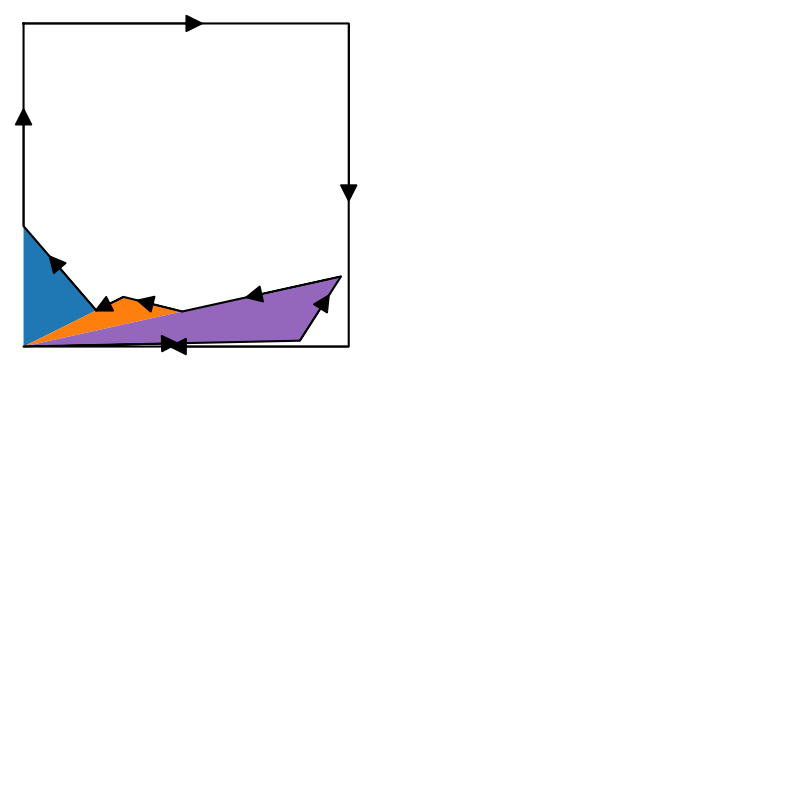

In [88]:
sqrt = int(np.sqrt(len(states_list)))+1
fig, axs = plt.subplots(sqrt, sqrt, figsize=(10,10))
for i in range(sqrt):
    for j in range(sqrt):
        axs[i,j].axis('off')

for n, state in enumerate(states_list):

    ax = axs[n%sqrt, n//sqrt] 
    ax.set_xlim([-0.5,12.5])
    ax.set_ylim([-0.5,12.5])
    for poly in state.used_polys:
        ax.fill(poly.xs, poly.ys)

    xs, ys = state.frame.xs, state.frame.ys

    ax.plot(xs, ys, color='k')
    for x, y, xn, yn in zip(xs[:-1], ys[:-1], xs[1:], ys[1:]):
        ax.arrow(x, y, (xn-x)/2, (yn-y)/2, head_width = 0.6, head_length = 0.6, fc='k', ec='k')
        